# 05.20 - Multi-Class Classification

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Most real-world classification problems have more than 2 classes. Multi-class strategies extend binary classifiers.

## 2. Why Does This Matter?

Binary classifiers are building blocks. Multi-class is the real world.

## 3. Prerequisites

- 05.03: Logistic regression (binary)
- 05.04: Classification metrics

## 4. Learning Objectives

- Understand One-vs-Rest and One-vs-One
- Apply binary classifiers to multi-class
- Evaluate with confusion matrix

## 5. Mental Model

OvR: Train K classifiers (one per class). Each says am I this class or not?
OvO: Train K*(K-1)/2 classifiers (one per pair). Majority vote.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 6. Multi-Class Strategies

In [2]:
wine = load_wine()
X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.2, random_state=42, stratify=wine.target
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Classes: " + str(list(wine.target_names)))

Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


In [3]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)
print("Random Forest (native): " + str(round(accuracy_score(y_test, y_pred_rf), 4)))

lr_ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
lr_ovr.fit(X_train_s, y_train)
y_pred_ovr = lr_ovr.predict(X_test_s)
print("Logistic Regression OvR: " + str(round(accuracy_score(y_test, y_pred_ovr), 4)))

lr_ovo = OneVsOneClassifier(LogisticRegression(max_iter=1000, random_state=42))
lr_ovo.fit(X_train_s, y_train)
y_pred_ovo = lr_ovo.predict(X_test_s)
print("Logistic Regression OvO: " + str(round(accuracy_score(y_test, y_pred_ovo), 4)))

Random Forest (native): 1.0
Logistic Regression OvR: 1.0
Logistic Regression OvO: 0.9722


## 7. Multi-Class Confusion Matrix

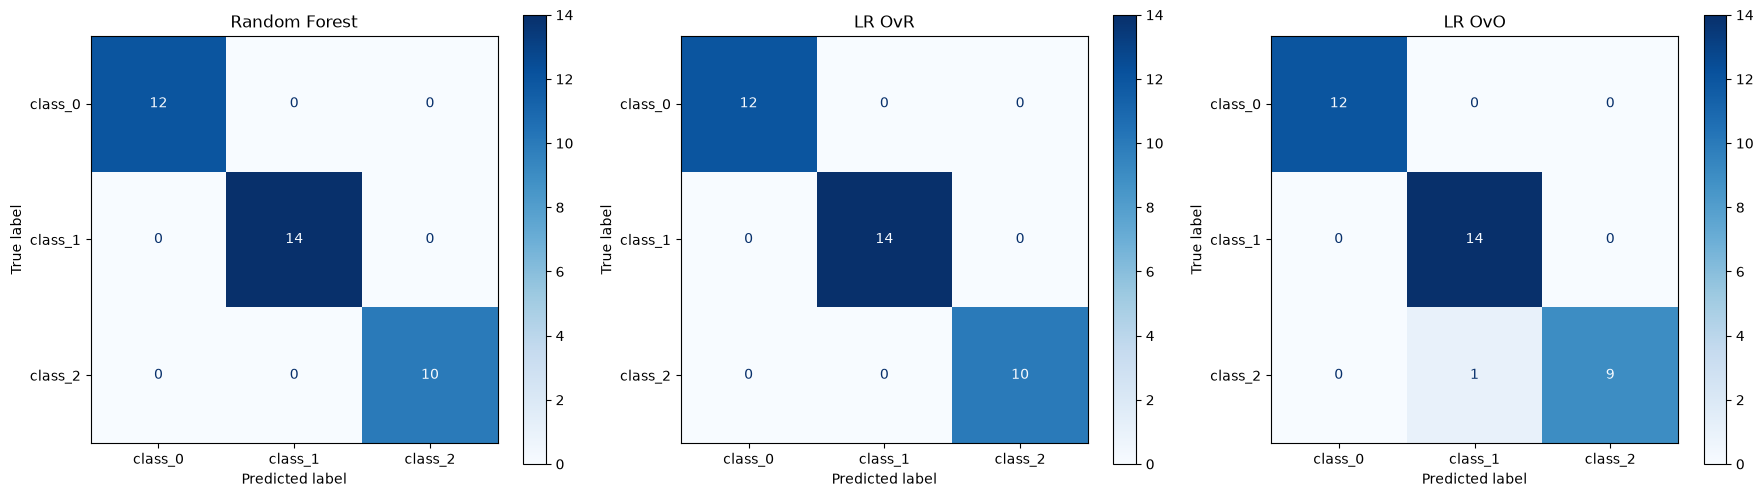

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, y_pred, title in zip(axes, [y_pred_rf, y_pred_ovr, y_pred_ovo],
                             ["Random Forest", "LR OvR", "LR OvO"]):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=wine.target_names, ax=ax, cmap="Blues")
    ax.set_title(title)
plt.tight_layout()
plt.savefig("multiclass_confusion.png", dpi=100, bbox_inches="tight")
plt.show()

In [5]:
print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=wine.target_names))

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## 8. Common Mistakes

1. Ignoring class imbalance
2. Using accuracy alone
3. Not using stratified splits

## 9. Coding Exercises

### Exercise 1: MNIST Multi-Class
Load digits, train RF, report accuracy and confusion matrix.

### Exercise 2: Iris OvR
Implement One-vs-Rest on Iris from scratch.

In [6]:
# EXERCISE 1: MNIST digits
from sklearn.datasets import load_digits
print("Exercise: Multi-class on digits dataset.")

Exercise: Multi-class on digits dataset.


In [7]:
# EXERCISE 2: Iris OvR from scratch
print("Exercise: Implement OvR from scratch.")

Exercise: Implement OvR from scratch.


## 10. Closed-Book Recall

1. What is One-vs-Rest?
2. What is One-vs-One?
3. How do you evaluate multi-class models?
4. When do models handle multi-class natively?

## 11. Teach-Back Questions

Explain OvR vs OvO. How confusion matrices work for multi-class.

## 12. Summary

Multi-class uses OvR or OvO. Many models handle it natively. Evaluate with confusion matrix and per-class metrics.

## 13. Further Experiment

1. Compare OvR and OvO on digits.
2. Implement multi-class from scratch.
3. Research softmax.

## Verification Status
```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: [numpy, pandas, matplotlib, scikit-learn]
OUTPUTS: PASS
LAST VERIFIED: 2026-08-30
```